# 04 · How many factors? How many shocks?

A dynamic factor model has two size parameters:

* **r**, the number of *static* factors — the dimension of the space spanned by the
  common component $\Lambda f_t$;
* **q ≤ r**, the number of *dynamic* (primitive) shocks driving the factors
  ($f_t = \sum_i A_i f_{t-i} + B u_t$, $B$ of rank $q$).

Bai & Ng (2002) choose r by penalised least squares,
$IC_{p,k}(r) = \ln V(r) + r\,g_k(N, T)$, where $V(r)$ is the average squared residual of
the panel after removing r principal components and $g_k$ is one of three penalties
that vanish more slowly than $\min(N, T)^{-1}$. Bai & Ng (2007) estimate q from the
eigenvalues of the covariance matrix of the residuals of a VAR on the estimated
factors: if only q shocks drive r factors, $r-q$ eigenvalues are (asymptotically)
zero. Their statistics compare normalised eigenvalues with a bound
$m / \min(N^{1/2-\delta}, T^{1/2-\delta})$, with tuning constants $\delta \in (0, 1/2)$
and $m > 0$.

This notebook (i) checks the criteria on simulated data with a known structure,
(ii) studies their sensitivity to `rmax`, `delta` and `m`, and (iii) applies them to
the US and Brazilian panels.

In [1]:
import sys
from pathlib import Path

HERE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
sys.path.insert(0, str(HERE.parent))

import numpy as np
import pandas as pd
from utils import SEED, display, md, setup, show

import nowcastbox as nb

setup()

## 1. A sanity check with known r

`load_simulated_dfm` draws a panel from a DFM with known parameters. With 3 factors,
the information criteria should recover r = 3 — but only once the cross-section is
large enough: Bai & Ng (2002) warn that the `PC` criteria over-select when
$\min(N, T)$ is small.

In [2]:
rows = {}
for n in (20, 60, 100):
    sim = nb.load_simulated_dfm(n_monthly=n, n_factors=3, n_periods=300, random_state=1)
    sel = nb.select_factors(sim.data.drop(["gdp"]), rmax=10)
    rows[f"N = {n}"] = sel.r_star_by_criterion
display(pd.DataFrame(rows).T.rename_axis("true r = 3"))

,IC1,IC2,IC3,PC1,PC2,PC3
true r = 3,,,,,,
N = 20,3,3,3,8,8,9
N = 60,3,3,3,3,3,3
N = 100,3,3,3,3,3,3


The `IC` criteria find r = 3 already with N = 20, while the `PC` criteria pick 8–9 —
the small-sample over-selection documented by Bai & Ng. `nowcastbox` uses `IC2` by
default (it is also the default of `nb.nowcast`), and warns when $\min(N, T) < 20$.

Number of factors - Bai & Ng (2002)
N (series): 100   T (periods): 298   rmax: 10
Selected (IC2): r* = 3
By criterion: IC1=3, IC2=3, IC3=3, PC1=3, PC2=3, PC3=3
Dropped periods (missing values): 2

                 V      IC1      IC2      IC3      PC1      PC2      PC3
n_factors                                                               
0          0.99664 -0.00336 -0.00336 -0.00336  0.99664  0.99664  0.99664
1          0.76992 -0.20382 -0.19996 -0.21541  0.79098  0.79239  0.78675
2          0.58996 -0.41243 -0.40470 -0.43561  0.63206  0.63489  0.62360
3          0.44136 -0.64498 -0.63339 -0.67975  0.50452  0.50875  0.49182
4          0.42903 -0.61567 -0.60021 -0.66202  0.51325  0.51889  0.49631
5          0.41759 -0.58506 -0.56574 -0.64300  0.52286  0.52992  0.50169
6          0.40634 -0.55472 -0.53153 -0.62425  0.53267  0.54114  0.50727
7          0.39566 -0.52372 -0.49667 -0.60485  0.54304  0.55292  0.51341
8          0.38505 -0.49326 -0.46234 -0.58597  0.55349  0.56478  0.51962


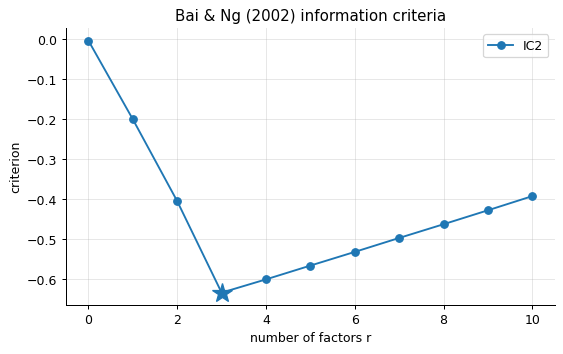

In [3]:
sim = nb.load_simulated_dfm(n_monthly=100, n_factors=3, n_periods=300, random_state=1)
sel = nb.select_factors(sim.data.drop(["gdp"]), rmax=10, criterion="IC2")
print(sel.summary())
fig = sel.plot("criteria", backend="matplotlib")
show(fig, "04_criteria_simulated")

## 2. A sanity check with q < r

Static factors often include *lags* of the dynamic factors. Below a single AR(1)
dynamic factor $g_t$ loads on the panel both contemporaneously and with one lag, so the
static factor vector is $F_t = (g_t, g_{t-1})'$: **r = 2 but q = 1**. The factor VAR
residuals then have a rank-one covariance matrix, which is what Bai & Ng (2007) detect.

In [4]:
rng = np.random.default_rng(SEED)
T, N = 300, 80
g = np.zeros(T + 1)
for t in range(1, T + 1):
    g[t] = 0.7 * g[t - 1] + rng.standard_normal()
lam0, lam1 = rng.normal(1.0, 0.5, N), rng.normal(0.0, 1.0, N)
X = np.outer(g[1:], lam0) + np.outer(g[:-1], lam1) + rng.standard_normal((T, N))
panel_q1 = pd.DataFrame(
    X,
    index=pd.period_range("2000-01", periods=T, freq="M"),
    columns=[f"x{i:02d}" for i in range(N)],
)
r_hat = nb.select_factors(panel_q1, rmax=8).r_star
q_sel = nb.select_shocks(panel_q1, n_factors=r_hat, factor_lags=1)
print(q_sel.summary())

Number of primitive shocks - Bai & Ng (2007)
N (series): 80   T (periods): 300
r (factors): 2   p (VAR lags): 1   matrix: covariance
delta: 0.1   D1: m=1.0, M_NT=0.17329   D2: m=1.0, M_NT=0.17329
Selected (D1): q* = 1
By statistic: D1=1, D2=1

   eigenvalue       D1       D2
k                              
1     0.25336  0.02039  0.02039
2     0.00517  0.00000  0.00000


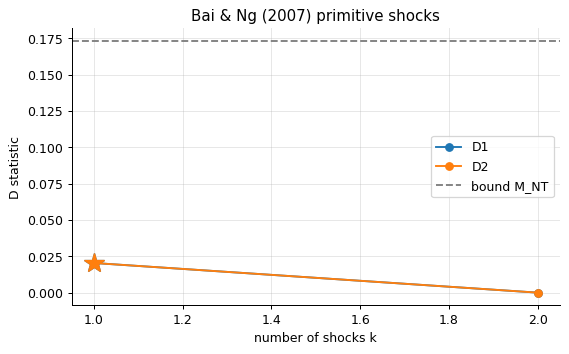

In [5]:
fig = q_sel.plot(backend="matplotlib")
show(fig, "04_shocks_simulated")

`select_factors` finds the two static factors and `select_shocks` correctly reports a
single primitive shock.

## 3. Sensitivity to `delta` and `m`

The Bai-Ng (2007) bound shrinks with $\min(N, T)^{1/2-\delta}$ and scales with `m`.
A larger `delta` or `m` raises the bound and makes the test more conservative
(fewer shocks). The grid below uses the simulated panel with three *independent*
dynamic factors (true q = r = 3).

In [6]:
x_sim = sim.data.drop(["gdp"])
grid = {
    (delta, m): nb.select_shocks(x_sim, n_factors=3, factor_lags=1, delta=delta, m=m).q_star
    for delta in (0.05, 0.1, 0.2, 0.3, 0.45)
    for m in (0.5, 1.0, 2.0)
}
q_grid = pd.Series(grid).unstack()  # noqa: PD010
q_grid.index.name, q_grid.columns.name = "delta", "m"
display(q_grid)

m,0.5,1.0,2.0
delta,,,
0.05,3,3,3
0.10,3,3,3
0.20,3,3,2
0.30,3,2,1
0.45,2,1,1


With the defaults suggested by Bai & Ng (small `delta`, `m` ≈ 1) the statistic recovers
q = 3; pushing `delta` towards 1/2 or `m` up quickly under-selects. In applied work
report q over a grid like this one rather than a single number.

## 4. Sensitivity to `rmax`

The criteria are minimised over $r \le r_{max}$. The `IC` criteria depend on `rmax`
only through the search range; the `PC` criteria also scale their penalty by
$\hat\sigma^2 = V(r_{max})$, so their minimiser can move when the grid grows. We use
the US GRS-like panel (notebook 03).

In [7]:
us = nb.load_us_grs_like()
us_panel = nb.prepare_panel(us.data, us.transform)
x_us = us_panel.drop(["GDPC1"])
rmax_table = pd.DataFrame(
    {rmax: nb.select_factors(x_us, rmax=rmax).r_star_by_criterion for rmax in (4, 6, 8, 10, 15)}
).T.rename_axis("rmax")
display(rmax_table)

,IC1,IC2,IC3,PC1,PC2,PC3
rmax,,,,,,
4,4,4,4,4,4,4
6,6,6,6,6,6,6
8,6,6,8,8,6,8
10,6,6,10,8,8,10
15,6,6,15,12,11,15


On real data the criteria disagree more: `IC2` picks around 6 factors once `rmax` is
large enough, `IC3` and the `PC` criteria run up to `rmax`. This is common in
macroeconomic panels, whose eigenvalues decay slowly (a few strong factors plus many
weak ones; Onatski, 2010). A sensible routine: look at the scree plot, use `IC2` as a
first guess, and choose the final r by pseudo real-time accuracy (notebook 08) —
GRS used r = 2 for nowcasting even though more factors are "significant".

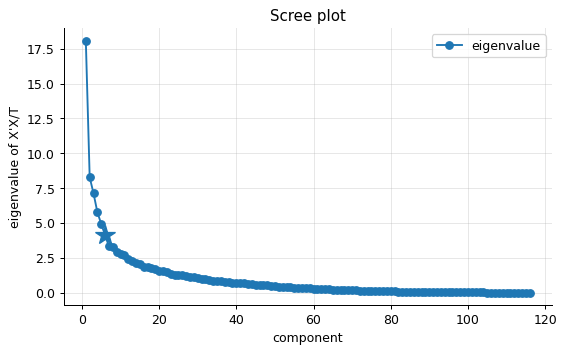

In [8]:
sel_us = nb.select_factors(x_us, rmax=10)
fig = sel_us.plot("eigenvalues", backend="matplotlib")
show(fig, "04_scree_us")

In [9]:
q_us = pd.DataFrame(
    {
        r: nb.select_shocks(x_us, n_factors=r, factor_lags=2).q_by_statistic
        for r in (2, 4, sel_us.r_star)
    }
).T.rename_axis("r")
display(q_us)

,D1,D2
r,,
2,2,2
4,3,3
6,3,4


## 5. The Brazilian panel

The Brazilian panel is noisier and shorter (2003–2026, with the 2020 shock). We run
the selection on 2004–2019 to keep the pandemic out of the principal components.

Brazil (2004–2019, N = 76, T = 153): IC2 selects **r = 5** (all criteria: {'IC1': 5, 'IC2': 5, 'IC3': 10, 'PC1': 8, 'PC2': 6, 'PC3': 10}); Bai-Ng (2007) D1 selects **q = 3** shocks.

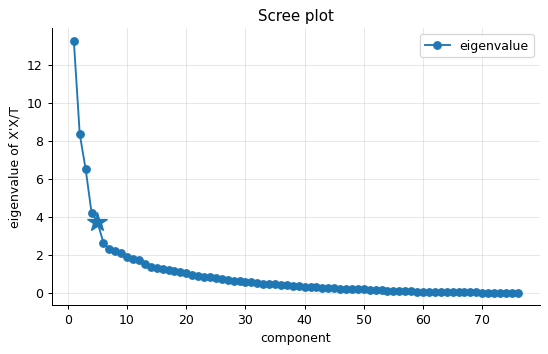

In [10]:
br = nb.load_brazil_nowcast()
br_panel = nb.prepare_panel(br.data, br.transform).truncate("2004-01", "2019-12")
x_br = br_panel.select(br_panel.monthly_columns)
sel_br = nb.select_factors(x_br, rmax=10)
q_br = nb.select_shocks(x_br, n_factors=sel_br.r_star, factor_lags=1)
md(
    f"Brazil (2004–2019, N = {sel_br.n_series}, T = {sel_br.n_periods}): "
    f"IC2 selects **r = {sel_br.r_star}** "
    f"(all criteria: {sel_br.r_star_by_criterion}); Bai-Ng (2007) D1 selects "
    f"**q = {q_br.q_star}** shocks."
)
fig = sel_br.plot("eigenvalues", backend="matplotlib")
show(fig, "04_scree_brazil")

## 6. Selecting predictors, not only factors

With very heterogeneous panels, removing series unrelated to the target before
extracting factors can improve forecasts (Bai & Ng, 2008, *targeted predictors*).
`select_targeted_predictors` ranks series by the *t*-statistic of their coefficient in
a regression of the target on the predictor (hard thresholding) or by LARS/elastic
net (soft thresholding).

In [11]:
tp = nb.select_targeted_predictors(us_panel, "GDPC1", method="hard")
md(
    f"Hard thresholding keeps **{tp.n_selected}** of {x_us.n_series} US predictors; the "
    f"top ten are: {', '.join(tp.selected[:10])} — employment, industrial production and "
    f"trade, the classic coincident indicators."
)

Hard thresholding keeps **70** of 116 US predictors; the top ten are: DMANEMP, MANEMP, USTPU, USGOOD, PAYEMS, USWTRADE, INDPRO, IPDMAT, USTRADE, IPMANSICS — employment, industrial production and trade, the classic coincident indicators.

### References

* Bai, J. & Ng, S. (2002). Determining the number of factors in approximate factor
  models. *Econometrica*, 70(1), 191–221.
* Bai, J. & Ng, S. (2007). Determining the number of primitive shocks in factor
  models. *JBES*, 25(1), 52–60.
* Bai, J. & Ng, S. (2008). Forecasting economic time series using targeted
  predictors. *Journal of Econometrics*, 146(2), 304–317.
* Onatski, A. (2010). Determining the number of factors from empirical distribution
  of eigenvalues. *Review of Economics and Statistics*, 92(4), 1004–1016.